In [1]:
import numpy as np
import matplotlib.pyplot as plt
import inspect
import pandas as pd
import os
from pathlib import Path
import xarray as xr
import spikeinterface as si
import spikeinterface.preprocessing as spp
from hypo_sleep.rec_utils import (
    get_filter_coeff,
    filter_recording,
    get_valid_times,
    resample_recording,
    reference_recording,
)
from hypo_sleep.session_helper import (
    get_spans,
    load_events,
    union_intervals,
    subtract_intervals,
)
from hypo_sleep import Session
from hypo_sleep.pipelines.spectra_event import down_filt_ref_rec

In [2]:
data_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/")
full_dict = {
    "none": {
        "dates": [
            "2025-02-18_09-19-26",
            "2025-02-20_08-58-57",
            "2025-03-20_09-01-41",
            "2025-02-24_09-00-29",
            "2025-02-26_09-05-08",
        ],
        "configs": [
            "5d77",
            "790d",
            "8a55",
            "3e4b",
            "d205",
        ],
        "animal": ["HYDO03", "HYDO03", "HYDO03", "HYDO04", "HYDO04"],
    },
    "sleep": {
        "dates": [
            "2025-02-19_08-59-23",
            "2025-03-03_08-55-10",
            "2025-02-25_09-06-23",
            "2025-03-07_08-52-44",
        ],
        "configs": [
            "d628",
            "c687",
            "073a",
            "9080",
        ],
        "animal": ["HYDO03", "HYDO03", "HYDO04", "HYDO04"],
    },
    "food": {
        "dates": [
            "2025-02-21_09-04-29",
            "2025-02-28_09-02-06",
            "2025-03-04_08-55-25",
        ],
        "configs": [
            "a964",
            "0674",
            "bc96",
        ],
        "animal": ["HYDO03", "HYDO03", "HYDO04"],
    },
}
depth_ordered_chs = np.array(
    [
        "24",
        "23",
        "25",
        "22",
        "8",
        "7",
        "9",
        "6",
        "15",
        "0",
        "14",
        "1",
        "26",
        "21",
        "27",
        "20",
        "10",
        "5",
        "28",
        "19",
        "11",
        "4",
        "29",
        "18",
        "12",
        "3",
        "30",
        "17",
        "13",
        "2",
        "31",
        "16",
    ]
)

In [3]:
config_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/")
session_dict = {}
animal_dict = full_dict["none"]
for animal, date, config_id in zip(
    animal_dict["animal"], animal_dict["dates"], animal_dict["configs"]
):
    session_dict[date] = Session(
        config_path, animal, date, config_id, **{"base_path": "remote"}
    )

KeyboardInterrupt: 

In [14]:
trigger_date_dict = {
    date: {
        trigger: {region: None for region in ["hyp", "ctx"]}
        for trigger in [
            "nrem-onset",
            "rem-onset",
            "wake-onset",
        ]  # ["so-peak", "spi-peak", "nrem-null"]
    }
    for date in session_dict.keys()
}
save_path = Path(data_path, "lfp_traces")
save_path.mkdir(parents=True, exist_ok=True)
trans_dict = {
    trans: {date: None for date in trigger_date_dict.keys()}
    for trans in ["NREM_REM", "NREM_WAKE", "REM_WAKE", "WAKE_NREM"]
}
for date, date_dict in trigger_date_dict.items():
    traces = []
    # trans_dict = {"NREM_REM": [], "NREM_WAKE": [], "REM_WAKE": [], "WAKE_NREM": []}
    for trigger, trig_dict in date_dict.items():
        for region, reg_data in trig_dict.items():
            if region == "ctx":
                continue
            manager = session_dict[date]
            filter_id = "low_lfp_0357"
            ref_id = "ctx_global_fe80" if region == "hyp" else "none_1da2"
            resample_id = "250_132b"
            params = {}
            params = {
                **params,
                **manager.param_sets["reference"][ref_id],
                "reference_id": ref_id,
                **manager.param_sets["resample"][resample_id],
                "resample_id": resample_id,
                **manager.param_sets["filter"][filter_id],
                "filter_id": filter_id,
                "chunk_window": 10,
                "spectra_window": 20,
                "Fs": 250,
                "region": region,
                "trigger_ch": 39,
            }
            rec = manager.hyp_rec
            rec_duration = manager.config["data"].get("rec_duration", None)
            if "null" in trigger.split("-")[1]:
                trigger_ch = params.get(f"trigger_ch")
                valid_spans_spi = load_events["spi"](manager, channel=trigger_ch)
                valid_spans_so = load_events["so"](manager, channel=trigger_ch)
                so_times = np.stack(
                    [valid_spans_so.down_crossing, valid_spans_so.end_crossing]
                ).T
                spi_times = np.stack([valid_spans_spi.start, valid_spans_spi.end]).T
                event_intervals = union_intervals(so_times, spi_times)
                valid_spans = subtract_intervals(
                    manager.state_dict["NREM"]["times"].T, event_intervals
                )
                trigger_ch_str = f"_{int(trigger_ch):02d}"
            elif trigger.split("-")[0] in ["so", "spi"]:
                trigger_ch = params.get(f"trigger_ch")
                valid_spans = load_events[trigger.split("-")[0]](
                    manager, channel=params.get("trigger_ch")
                )
                trigger_ch_str = f"_{int(trigger_ch):02d}"
            else:
                trigger_ch_str = ""
                valid_spans = None

            rec = down_filt_ref_rec(manager, rec, rec_dur=rec_duration, **params)
            chunks = get_spans(manager, trigger, valid_spans=valid_spans, **params)
            time_span = (
                np.arange(
                    int(params.get("spectra_window", 2) * params.get("Fs", 250)) * 2 + 1
                )
                - int(params.get("spectra_window", 2) * params.get("Fs", 250))
            ) / params.get("Fs", 250)
            traces = []
            channels = (
                depth_ordered_chs[::-1] if region == "hyp" else rec.get_channel_ids()
            )
            # for ch in channels:
            #     if str(ch) in rec.get_channel_ids():
            #         chunk_traces = []
            for chunk_ind, (start, stop) in enumerate(chunks):
                if start - 0.05 < rec.get_start_time():
                    continue
                if stop - start < params.get("spectra_window", 1):
                    if params.get("verbose", False):
                        print(
                            f"Skipping chunk {start}-{stop} for channel {ch} due to insufficient length."
                        )
                    continue
                if stop + 0.05 > rec.get_end_time():
                    if params.get("verbose", False):
                        print(
                            f"skipping chunk with stop: {stop:.02f} for channel {ch}. Recording is only {rec.get_end_time():.02f}s long."
                        )
                    continue
                tmp_rec = rec.time_slice(
                    start_time=start - 0.05,
                    end_time=stop + 0.05,
                )
                tmp_trace = tmp_rec.get_traces(channel_ids=channels, return_in_uV=True)
                half_arr_size = tmp_trace.shape[0] // 2
                offset = half_arr_size - int(
                    params.get("spectra_window", 2) * params.get("Fs", 250)
                )
                snippet_time = tmp_rec.get_times()[offset:-offset]
                start_ind = rec.time_to_sample_index(snippet_time[1])
                stop_ind = rec.time_to_sample_index(snippet_time[-2])
                start_state = None
                for tmp_state, tmp_state_dict in manager.state_dict.items():
                    if tmp_state_dict["mask"][start_ind]:
                        start_state = tmp_state
                    if tmp_state_dict["mask"][stop_ind]:
                        stop_state = tmp_state

                traces.append(
                    xr.DataArray.from_dict(
                        {
                            "data": tmp_trace[offset:-offset, :].T[:, :, np.newaxis],
                            "dims": ["channel", "time", "trial"],
                            "coords": {
                                "channel": {"dims": "channel", "data": channels},
                                "time": {"dims": "time", "data": time_span},
                                "trial": {"dims": "trial", "data": [chunk_ind]},
                                "start": {
                                    "dims": "trial",
                                    "data": [snippet_time[0]],
                                },
                                "stop": {
                                    "dims": "trial",
                                    "data": [snippet_time[-1]],
                                },
                                "start_state": {
                                    "dims": "trial",
                                    "data": [start_state],
                                },
                                "stop_state": {
                                    "dims": "trial",
                                    "data": [stop_state],
                                },
                                "region": {"dims": "trial", "data": [region]},
                                # "epoch": {
                                #     "dims": "trial",
                                #     "data": [chunk_epoch[chunk_ind]],
                                # },
                            },
                            # "name": f"{ch}",
                        }
                    )
                )
                # traces.append(xr.concat(chunk_traces, dim="trial"))
            full_traces = xr.concat(
                traces, dim="trial"
            )  # dim=pd.Index(channels, name="channel"))
            for tmp_state in ["NREM", "REM", "WAKE"]:
                if tmp_state == trigger.split("-")[0].upper():
                    continue
                if (
                    f"{tmp_state}_{trigger.split("-")[0].upper()}"
                    not in trans_dict.keys()
                ):
                    continue
                trans_dict[f"{tmp_state}_{trigger.split('-')[0].upper()}"][date] = (
                    full_traces.set_xindex("start_state").sel(start_state=tmp_state)
                )
    # full_traces = full_traces.assign_coords({"epoch": ("trial", chunk_epoch)})
    # full_traces.name = f"{date}_{region}_{trigger}"
    # # full_traces.get_index(["epoch", "trial"])
    # # epoch_file = full_traces.epoch.sortby("epoch")
    # # epoch_file.name = "epoch"
    # # epoch_file.to_netcdf(
    # #     Path(save_path, f"{full_traces.name}_epochs.nc"),
    # #     engine="h5netcdf",
    # # )
    # ch_file = full_traces.channel
    # ch_file.name = "channel"
    # ch_file.to_netcdf(
    #     Path(save_path, f"{full_traces.name}_chs.nc"),
    #     engine="h5netcdf",
    # )
    # full_traces.to_netcdf(
    #     Path(save_path, f"{full_traces.name}.nc"), engine="h5netcdf"
    # )
    # # trigger_date_dict[date][region][trigger] = full_traces

/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: Use

In [16]:
trans_dict["NREM_REM"]["2025-02-18_09-19-26"].time

<xarray.DataArray 'time' (time: 10001)> Size: 80kB
array([-20.   , -19.996, -19.992, ...,  19.992,  19.996,  20.   ],
      shape=(10001,))
Coordinates:
  * time     (time) float64 80kB -20.0 -20.0 -19.99 -19.99 ... 19.99 20.0 20.0

In [17]:
save_path = Path(data_path, "lfp_traces")
save_path.mkdir(parents=True, exist_ok=True)
for trans, trig_data in trans_dict.items():
    for date, data in trig_data.items():
        tmp_xr = data.assign_coords({"trial": ("trial", np.arange(data.trial.size))})
        tmp_xr.name = f"{date}_hyp_{trans}"
        ch_file = tmp_xr.channel
        ch_file.name = "channel"
        ch_file.to_netcdf(
            Path(save_path, f"{tmp_xr.name}_chs.nc"),
            engine="h5netcdf",
        )
        tmp_xr.to_netcdf(Path(save_path, f"{tmp_xr.name}.nc"), engine="h5netcdf")

### EVENT EXTRACTION

In [5]:
## FOR EVENT TRIGGERS
trigger_date_dict = {
    date: {
        trigger: {region: None for region in ["hyp", "ctx"]}
        for trigger in ["so-peak", "spi-peak", "nrem-null"]
    }
    for date in session_dict.keys()
}
save_path = Path(data_path, "lfp_traces")
save_path.mkdir(parents=True, exist_ok=True)
for date, date_dict in trigger_date_dict.items():
    for trigger, trig_dict in date_dict.items():
        for region, reg_data in trig_dict.items():
            manager = session_dict[date]
            filter_id = "low_lfp_0357"
            ref_id = "ctx_global_fe80" if region == "hyp" else "none_1da2"
            resample_id = "250_132b"
            params = {}
            params = {
                **params,
                **manager.param_sets["reference"][ref_id],
                "reference_id": ref_id,
                **manager.param_sets["resample"][resample_id],
                "resample_id": resample_id,
                **manager.param_sets["filter"][filter_id],
                "filter_id": filter_id,
                "chunk_window": 1,
                "spectra_window": 2,
                "Fs": 250,
                "region": region,
                "trigger_ch": 39,
            }
            rec = manager.hyp_rec
            rec_duration = manager.config["data"].get("rec_duration", None)
            if "null" in trigger.split("-")[1]:
                trigger_ch = params.get(f"trigger_ch")
                valid_spans_spi = load_events["spi"](manager, channel=trigger_ch)
                valid_spans_so = load_events["so"](manager, channel=trigger_ch)
                so_times = np.stack(
                    [valid_spans_so.down_crossing, valid_spans_so.end_crossing]
                ).T
                spi_times = np.stack([valid_spans_spi.start, valid_spans_spi.end]).T
                event_intervals = union_intervals(so_times, spi_times)
                valid_spans = subtract_intervals(
                    manager.state_dict["NREM"]["times"].T, event_intervals
                )
                trigger_ch_str = f"_{int(trigger_ch):02d}"
            elif trigger.split("-")[0] in ["so", "spi"]:
                trigger_ch = params.get(f"trigger_ch")
                valid_spans = load_events[trigger.split("-")[0]](
                    manager, channel=params.get("trigger_ch")
                )
                trigger_ch_str = f"_{int(trigger_ch):02d}"
            else:
                trigger_ch_str = ""
                valid_spans = None

            rec = down_filt_ref_rec(manager, rec, rec_dur=rec_duration, **params)
            chunks = get_spans(manager, trigger, valid_spans=valid_spans, **params)
            chunk_epoch = np.full(len(chunks), fill_value=np.nan, dtype=int)

            # chunk_epoch = {
            #     epoch_ind: np.where(
            #         (np.array([c[0] for c in chunks]) >= start)
            #         & (np.array([c[1] for c in chunks]) <= stop)
            #     )[0]
            #     for epoch_ind, (start, stop) in enumerate(
            #         manager.state_dict["NREM"]["times"].T
            #     )
            # }
            for epoch_ind, (ep_start, ep_stop) in enumerate(
                manager.state_dict["NREM"]["times"].T
            ):
                chunk_inds = np.where(
                    (np.array([c[0] for c in chunks]) >= ep_start)
                    & (np.array([c[1] for c in chunks]) <= ep_stop)
                )[0]
                chunk_epoch[chunk_inds] = epoch_ind
            time_span = (
                np.arange(
                    int(params.get("spectra_window", 2) * params.get("Fs", 250)) * 2 + 1
                )
                - int(params.get("spectra_window", 2) * params.get("Fs", 250))
            ) / params.get("Fs", 250)
            traces = []
            channels = (
                depth_ordered_chs[::-1] if region == "hyp" else rec.get_channel_ids()
            )
            for ch in channels:
                if str(ch) in rec.get_channel_ids():
                    chunk_traces = []
                    for chunk_ind, (start, stop) in enumerate(chunks):
                        if start - 0.05 < rec.get_start_time():
                            continue
                        if stop - start < params.get("spectra_window", 1):
                            if params.get("verbose", False):
                                logger.info(
                                    f"Skipping chunk {start}-{stop} for channel {ch} due to insufficient length."
                                )
                            continue
                        if stop + 0.05 > rec.get_end_time():
                            if params.get("verbose", False):
                                logger.info(
                                    f"skipping chunk with stop: {stop:.02f} for channel {ch}. Recording is only {rec.get_end_time():.02f}s long."
                                )
                            continue
                        tmp_rec = rec.time_slice(
                            start_time=start - 0.05,
                            end_time=stop + 0.05,
                        )
                        tmp_trace = tmp_rec.get_traces(
                            channel_ids=[ch], return_in_uV=True
                        )
                        half_arr_size = tmp_trace.flatten().size // 2
                        offset = half_arr_size - int(
                            params.get("spectra_window", 2) * params.get("Fs", 250)
                        )
                        snippet_time = tmp_rec.get_times()[offset:-offset]
                        start_ind = rec.time_to_sample_index(snippet_time[1])
                        stop_ind = rec.time_to_sample_index(snippet_time[-2])
                        for tmp_state, tmp_state_dict in manager.state_dict.items():
                            if tmp_state_dict["mask"][start_ind]:
                                start_state = tmp_state
                            if tmp_state_dict["mask"][stop_ind]:
                                stop_state = tmp_state

                        chunk_traces.append(
                            xr.DataArray.from_dict(
                                {
                                    "data": tmp_trace[offset:-offset],
                                    "dims": ["time", "trial"],
                                    "coords": {
                                        "time": {"dims": "time", "data": time_span},
                                        "trial": {"dims": "trial", "data": [chunk_ind]},
                                        "epoch": {
                                            "dims": "trial",
                                            "data": [chunk_epoch[chunk_ind]],
                                        },
                                    },
                                    "name": f"{ch}",
                                }
                            )
                        )
                    traces.append(xr.concat(chunk_traces, dim="trial"))
            full_traces = xr.concat(traces, dim=pd.Index(channels, name="channel"))
            # full_traces = full_traces.assign_coords({"epoch": ("trial", chunk_epoch)})
            trigger_date_dict[date][trigger][region] = full_traces
# full_traces.name = f"{date}_{region}_{trigger}"
# # # full_traces.get_index(["epoch", "trial"])
# epoch_file = full_traces.epoch.sortby("epoch")
# epoch_file.name = "epoch"
# epoch_file.to_netcdf(
#     Path(save_path, f"{full_traces.name}_epochs.nc"),
#     engine="h5netcdf",
# )
# ch_file = full_traces.channel
# ch_file.name = "channel"
# ch_file.to_netcdf(
#     Path(save_path, f"{full_traces.name}_chs.nc"),
#     engine="h5netcdf",
# )
# full_traces.to_netcdf(
#     Path(save_path, f"{full_traces.name}.nc"), engine="h5netcdf"
# )
# # # trigger_date_dict[date][region][trigger] = full_traces

/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: Use

In [6]:
trig_epochs = {trig: [] for trig in ["so-peak", "spi-peak", "nrem-null"]}

for trig, tmp_trig in trig_epochs.items():
    for date, date_dict in trigger_date_dict.items():
        if date in ["2025-02-24_09-00-29"]:
            continue
        tmp_trig.append(date_dict[trig]["hyp"].groupby("epoch").mean("trial"))

In [7]:
coords_1D = [
    (elem,)
    for elem in session_dict[date].hyp_rec.get_channel_locations(
        channel_ids=depth_ordered_chs[::-1]
    )[:, 1]
]
coords_2D = [
    elem
    for elem in session_dict[date].hyp_rec.get_channel_locations(
        channel_ids=depth_ordered_chs[::-1]
    )
]
trig_csd = {"1D": {}, "2D": {}}
for trig, data in trig_epochs.items():
    tmp_data = xr.concat(data, dim="epoch")

    trig_sig = AnalogSignal(
        tmp_data.mean(dim="epoch").to_numpy().T, units="uV", sampling_rate=250 * pq.Hz
    )
    ## 1D CSD
    trig_sig.annotate(coordinates=coords_1D * pq.um)
    csd_1D = estimate_csd(
        trig_sig,
        method="KCSD1D",
        **{
            # "xmin": 0,
            # "xmax": 60,
            # "ymin": 0,
            # "ymax": 775,
            # "gdx": 1.2,
            # "gdy": 25,
            "n_src_init": 2000,
            # "lambd": 0.001,
        },
    )
    trig_csd["1D"][trig] = csd_1D

    ## 2D CSD
    trig_sig = AnalogSignal(
        tmp_data.mean(dim="epoch").to_numpy().T, units="uV", sampling_rate=250 * pq.Hz
    )
    trig_sig.annotate(coordinates=coords_2D * pq.um)
    csd_2D = estimate_csd(
        trig_sig,
        method="KCSD2D",
        **{
            # "xmin": 0,
            # "xmax": 0.06,
            # "ymin": 0,
            # "ymax": 0.775,
            # "gdx": 1.2,
            # "gdy": 12,
            "n_src_init": 2000,
            # "lambd": 0.001,
        },
    )
    trig_csd["2D"][trig] = csd_2D

No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.0011006941712522092
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.00012115276586285876
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.0011006941712522092
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.0011006941712522092


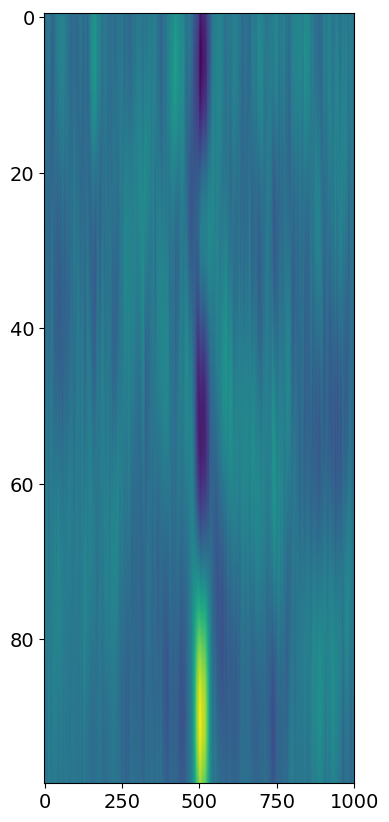

In [8]:
fig, ax = plt.subplots(figsize=(4, 10))
ax.imshow(trig_csd["2D"]["so-peak"].mean(axis=1).T, aspect="auto")

In [ ]:
from sklearn.mixture import BayesianGaussianMixture

X = np.array(tmp_csd).mean(axis=1)
bgm = BayesianGaussianMixture(
    n_components=10,
    random_state=42,
    n_init=100,
).fit(X)

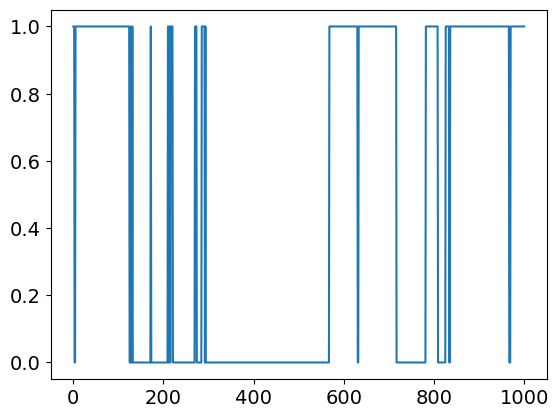

In [18]:
plt.plot(bgm.predict(X))

In [ ]:
np.array(tmp_csd).mean(axis=1)

(99, 1001)

Text(0.5, 0.01, 'Lateral Distance (µm)')

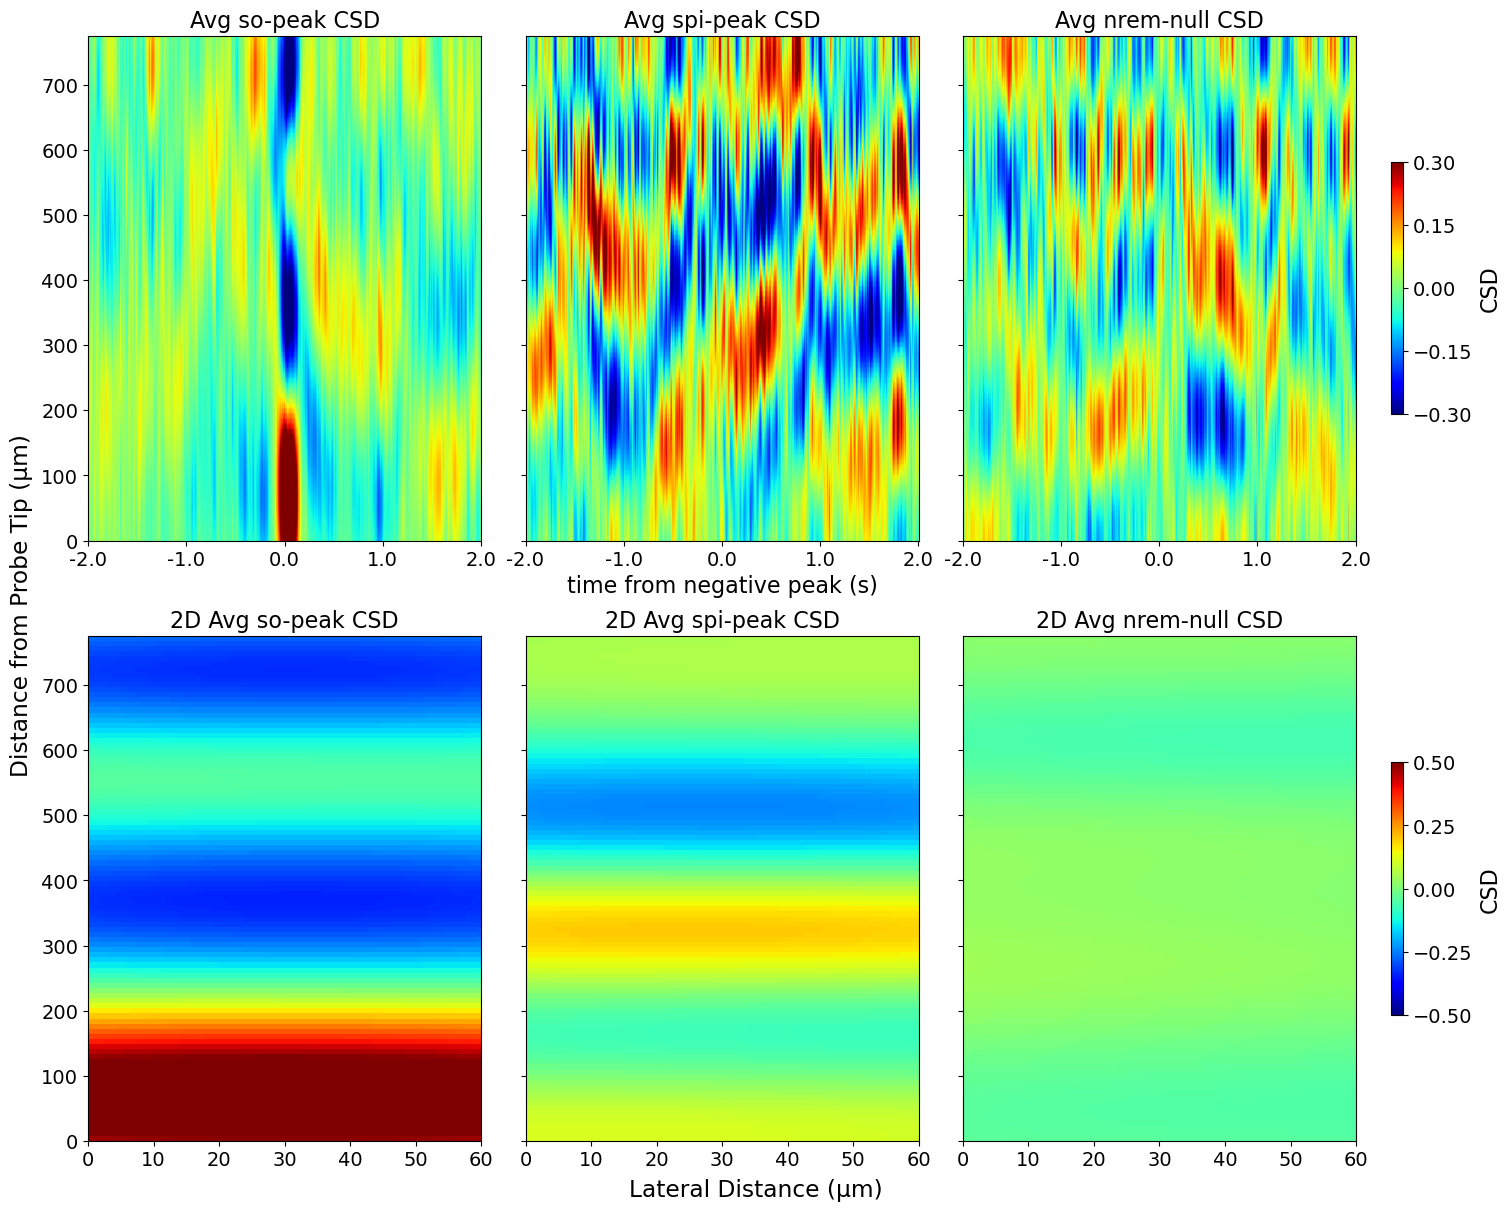

In [9]:
fig, axs = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 12),
    constrained_layout=True,
    sharey=True,
)
for ax, (trig, tmp_csd) in zip(axs[0, :].ravel(), trig_csd["2D"].items()):

    h1 = ax.imshow(
        np.array(tmp_csd).mean(axis=1).T,
        aspect="auto",
        extent=[0, 1001, 0, 775],
        vmin=-0.3,
        vmax=0.3,
        cmap="jet",
    )
    ax.set_xticks(np.arange(0, 1001, 250), labels=(np.arange(0, 1001, 250) - 500) / 250)
    ax.set_title(f"Avg {trig} CSD")
cbar = fig.colorbar(
    h1, ax=axs[0, -1], shrink=0.5, label="CSD", ticks=[-0.3, -0.15, 0.0, 0.15, 0.3]
)
axs[0, 1].set_xlabel("time from negative peak (s)")

for ax, (trig, tmp_csd) in zip(axs[1, :].ravel(), trig_csd["2D"].items()):

    h2 = ax.imshow(
        np.array(tmp_csd)[500, :, :].T,
        aspect="auto",
        extent=[0, 60, 0, 775],
        vmin=-0.5,
        vmax=0.5,
        cmap="jet",
    )
    # ax.set_xticks(np.arange(0, 60, 10), labels=(np.arange(0, 60, 10)))
    ax.set_title(f"2D Avg {trig} CSD")
cbar = fig.colorbar(
    h2, ax=axs[1, -1], shrink=0.5, label="CSD", ticks=[-0.5, -0.25, 0.0, 0.25, 0.5]
)
fig.supylabel("Distance from Probe Tip (µm)")
fig.supxlabel("Lateral Distance (µm)")

Text(0.5, 0.01, 'Lateral Distance (µm)')

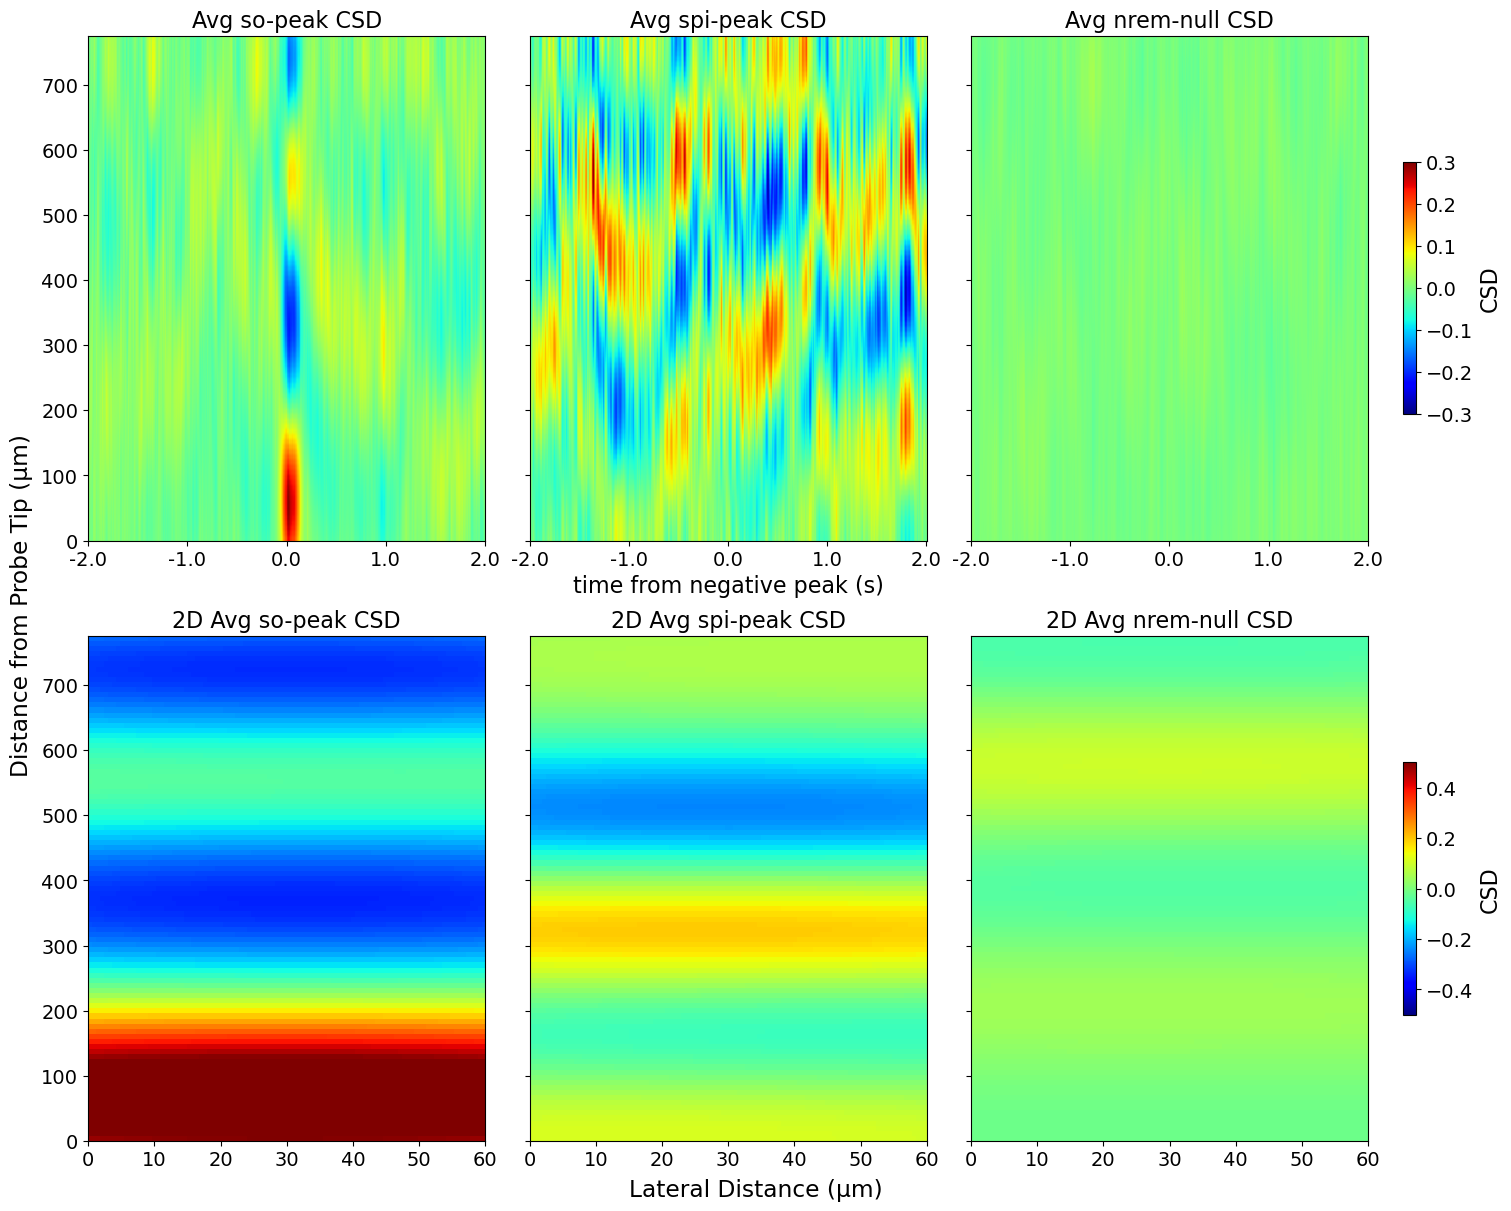

In [ ]:
fig, axs = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 12),
    constrained_layout=True,
    sharey=True,
)
for ax, (trig, tmp_csd) in zip(axs[0, :].ravel(), trig_csd["1D"].items()):

    h1 = ax.imshow(
        np.array(tmp_csd).T,
        aspect="auto",
        extent=[0, 1001, 0, 775],
        vmin=-0.3,
        vmax=0.3,
        cmap="jet",
    )
    ax.set_xticks(np.arange(0, 1001, 250), labels=(np.arange(0, 1001, 250) - 500) / 250)
    ax.set_title(f"Avg {trig} CSD")
cbar = fig.colorbar(
    h1,
    ax=axs[0, -1],
    shrink=0.5,
    label="CSD",  # ticks=[-0.5, -0.25, 0.0, 0.25, 0.5]
)
axs[0, 1].set_xlabel("time from negative peak (s)")

for ax, (trig, tmp_csd) in zip(axs[1, :].ravel(), trig_csd["2D"].items()):

    h2 = ax.imshow(
        np.array(tmp_csd)[500, :, :].T,
        aspect="auto",
        extent=[0, 60, 0, 775],
        vmin=-0.5,
        vmax=0.5,
        cmap="jet",
    )
    # ax.set_xticks(np.arange(0, 60, 10), labels=(np.arange(0, 60, 10)))
    ax.set_title(f"2D Avg {trig} CSD")
cbar = fig.colorbar(
    h2,
    ax=axs[1, -1],
    shrink=0.5,
    label="CSD",  # ticks=[-0.5, -0.25, 0.0, 0.25, 0.5]
)
fig.supylabel("Distance from Probe Tip (µm)")
fig.supxlabel("Lateral Distance (µm)")

In [57]:
full_traces = xr.concat(traces, dim=pd.Index(channels, name="channel"))

In [70]:
full_traces.set_xindex("start_state").sel(start_state="NREM").trial.values

array([ 1,  2,  3,  4,  6,  7,  9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
       21, 23, 25, 26, 27, 29, 30, 31, 32, 33, 34, 35, 37, 38, 40, 41, 44,
       47, 52, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69,
       70, 71, 72, 74, 75, 76, 79, 80, 81, 82])

In [91]:
time_span = (
    np.arange(int(params.get("spectra_window", 2) * params.get("Fs", 250)) * 2 + 1)
    - int(params.get("spectra_window", 2) * params.get("Fs", 250))
) / params.get("Fs", 250)
traces = []
for ch in depth_ordered_chs[::-1]:
    if str(ch) in rec.get_channel_ids():
        chunk_traces = []
        for chunk_ind, (start, stop) in enumerate(chunks):
            if start - 0.05 < rec.get_start_time():
                chunk_remove.append(chunk_ind)
                continue
            if stop - start < params.get("spectra_window", 1):
                chunk_remove.append(chunk_ind)
                if params.get("verbose", False):
                    logger.info(
                        f"Skipping chunk {start}-{stop} for channel {ch} due to insufficient length."
                    )
                continue
            if stop + 0.05 > rec.get_end_time():
                chunk_remove.append(chunk_ind)
                if params.get("verbose", False):
                    logger.info(
                        f"skipping chunk with stop: {stop:.02f} for channel {ch}. Recording is only {rec.get_end_time():.02f}s long."
                    )
                continue
            tmp_rec = rec.time_slice(
                start_time=start - 0.05,
                end_time=stop + 0.05,
            )
            tmp_trace = tmp_rec.get_traces(channel_ids=[ch], return_in_uV=True)
            half_arr_size = tmp_trace.flatten().size // 2
            offset = half_arr_size - int(
                params.get("spectra_window", 2) * params.get("Fs", 250)
            )
            chunk_traces.append(
                xr.DataArray.from_dict(
                    {
                        "data": tmp_trace.flatten()[offset:-offset],
                        "dims": "time",
                        "coords": {"time": {"dims": "time", "data": time_span}},
                        "name": f"{ch}",
                    }
                )
            )
        traces.append(xr.concat(chunk_traces, dim="trial"))
full_traces = xr.concat(traces, dim="channel")
full_traces.name = "depth-ordered"

In [93]:
full_traces

<xarray.DataArray 'depth-ordered' (channel: 32, trial: 3069, time: 1001)> Size: 393MB
array([[[ 5.18986473e+01,  5.50651245e+01,  7.63878403e+01, ...,
         -5.37283182e+00, -1.94579639e+01, -3.37075710e+00],
        [-4.33894043e+01, -2.17765884e+01, -4.57166672e+00, ...,
          2.65554714e+01,  3.53694725e+01,  4.27618752e+01],
        [ 7.30024109e+01,  4.56238441e+01,  5.59667282e+01, ...,
         -6.43266449e+01, -4.85229225e+01, -4.69066963e+01],
        ...,
        [ 1.42009010e+01,  1.61265755e+01, -8.74870718e-01, ...,
         -2.61857796e+01, -2.07748852e+01, -3.79504471e+01],
        [-8.33339691e+01, -7.72915115e+01, -7.55480423e+01, ...,
         -1.16928005e+01, -5.83253145e+00, -9.57144165e+00],
        [-3.10011406e+01, -2.41017380e+01, -3.44839897e+01, ...,
         -1.92974606e+01, -3.12401581e+01, -3.59051208e+01]],

       [[ 3.34197593e+00, -6.88319397e+00,  1.38868771e+01, ...,
         -1.53634949e+01, -1.19774637e+01,  4.36765957e+00],
        [-2.70625591e+01,  9.06829387e-02,  1.34269981e+01, ...,
         -4.19583321e+00, -1.13687773e+01, -9.99072742e+00],
        [ 7.06582413e+01,  7.95319138e+01,  7.91527557e+01, ...,
         -1.09858913e+01, -2.12020855e+01, -2.38933601e+01],
...
          4.63746529e+01,  4.98983498e+01,  2.37458458e+01],
        [-6.71402645e+00,  4.12427306e-01,  7.03901978e+01, ...,
          3.61158991e+00,  2.11799850e+01,  2.55557728e+01],
        [ 3.62048073e+01, -2.47677460e+01, -3.04817410e+01, ...,
         -6.59008942e+01, -1.12244438e+02, -1.31602112e+02]],

       [[ 3.88873076e+00, -9.38753986e+00, -2.03099206e-01, ...,
         -1.51727724e+01, -2.03113194e+01, -2.09064293e+01],
        [ 3.91492195e+01,  3.12336407e+01,  2.93529530e+01, ...,
          9.78806496e+00,  3.30647545e+01,  2.71256886e+01],
        [-2.38617592e+01, -5.57340670e+00, -1.19786339e+01, ...,
          1.12187634e+01,  8.91619444e-01, -2.38249227e-01],
        ...,
        [-9.51258469e+00,  1.23239636e+00, -3.80012417e+00, ...,
         -1.98336277e+01, -1.19439268e+01,  1.55649269e+00],
        [-7.72987747e+01, -1.25982231e+02, -1.33509232e+02, ...,
         -7.86126633e+01, -1.12131905e+02, -5.64637184e+01],
        [ 6.52637625e+00,  7.06893778e+00,  3.51839561e+01, ...,
         -1.83117046e+01, -2.85401592e+01,  3.64183688e+00]]],
      shape=(32, 3069, 1001), dtype=float32)
Coordinates:
  * time     (time) float64 8kB -2.0 -1.996 -1.992 -1.988 ... 1.992 1.996 2.0
Dimensions without coordinates: channel, trial